Opening image: /Users/mrmicfatfat/Documents/VSCodeFiles/Defects-AI-Analyzer/3DPrintDefectDataset/defected/no_bottom_7.jpg
Total images found: 1557
Total labels found: 1557
Training images: 1245
Testing images: 312

--- Label Distribution ---
Original: [798 759]
Training: [638 607]
Testing: [160 152]


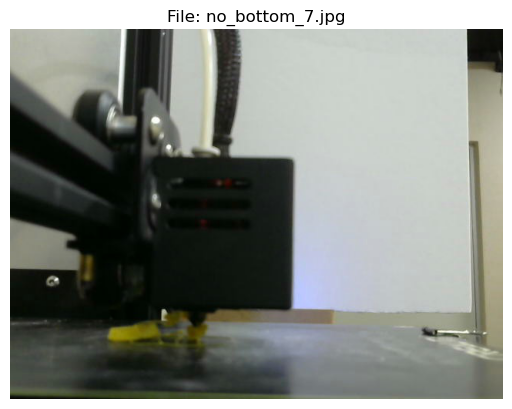

--- Pytorch Dataset is working. ---
Image shape: torch.Size([3, 224, 224])
Label: 1
--- DataLoaders are working.---
Shape of one batch of images: torch.Size([32, 3, 224, 224])
Shape of one batch of labels: torch.Size([32])
--- Model Created Successfully---
Model output shape: torch.Size([32, 2])
--- Loss Function and Optimizer are ready. ---
Using device: mps
Epoch [1/10], Loss: 0.7983, Test Accuracy: 83.65%
--- Training Finished!---
Epoch [2/10], Loss: 0.1368, Test Accuracy: 99.04%
--- Training Finished!---
Epoch [3/10], Loss: 0.0428, Test Accuracy: 99.68%
--- Training Finished!---
Epoch [4/10], Loss: 0.0272, Test Accuracy: 99.04%
--- Training Finished!---


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

#Set os to 1 for Windows, any other number for MacOS file locations of dataset
is_windows = 0
#dataset locations
if is_windows == 0:
    dataset_path = '/Users/mrmicfatfat/Documents/VSCodeFiles/Defects-AI-Analyzer/3DPrintDefectDataset'
else:
    dataset_path = r'C:\Users\joseph\Documents\VSCodeProjects\Defects-AI-Analyzer\3DPrintDefectDataset'

image_paths = []
labels = []
#Defect Folder path
defect_folder = os.path.join(dataset_path, 'defected')
for filename in os.listdir(defect_folder):
    full_path = os.path.join(defect_folder, filename)
    image_paths.append(full_path)
    labels.append(1)

defect_filenames = os.listdir(defect_folder)
image_to_open = defect_filenames[30]
full_image_path = os.path.join(defect_folder, image_to_open)

#Non-defect Folder path
non_defect_folder = os.path.join(dataset_path, 'non-defected')
for filename in os.listdir(non_defect_folder):
    full_path = os.path.join(non_defect_folder, filename)
    image_paths.append(full_path)
    labels.append(0)

# Data Pre-Processing:
# Ensures labels are in NumPy
labels_array = np.array(labels)
# This splits up our dataset. This is critical!
# test_size sets up 20% of all images for the model to test itself on after it has studied 80% of the material.
# For more context, if you are about to take an exam, you need to study. So the model studies 80% before testing itself on the last 20%.
# By setting random_state to a number (any number, 42 is just a convention),
# This ensures that every time the code is run, the exact same random split is achieved.
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, 
    labels_array, 
    test_size=0.2, 
    random_state=42,
    stratify=labels_array
)


print(f"Opening image: {full_image_path}")
print(f"Total images found: {len(image_paths)}")
print(f"Total labels found: {len(labels)}")

print(f"Training images: {len(train_paths)}")
print(f"Testing images: {len(test_paths)}")

print("\n--- Label Distribution ---")
# 'np.bincount' is a fast way to count how many 0s and 1s we have
print(f"Original: {np.bincount(labels_array)}")
print(f"Training: {np.bincount(train_labels)}")
print(f"Testing: {np.bincount(test_labels)}")
try:
    #Uses the Pillow plugin to open the image
    img = Image.open(full_image_path)

    #Numpy converts this image to an array
    img_array = np.array(img)

    #Uses matplotlib to display the image
    plt.imshow(img_array)
    plt.title(f"File: {image_to_open}")
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"An error occured while trying to open {e}")
# Stuff to think about:
# Ensembles (XGBoost) is really good for tree-based models.
# Tree-Based models are best for tabular data with mixed types, when you need feature importance.
# Other Models: Neural Networks (MLPs) are for large datasets and complex patterns. 
# It is a flexible architecture but needs more data (much more than 2000)
# Need to do data preprocessing!
# Tuning Hyperparameters:
# What your model learns to fit your dataset. Hyperparameters: Knobs you control to determine expressivity and contraints on your model.
# Why tune hyperparameters?: Can improve performance and balance model complexity.
# This week!:
# Train a baseline, tune hyperparameters, and record results.

# Work on PyTorch Code
# Need to define the Transforms, start with resizing dataset images to 224x244 and scale pixels from [0, 1]
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
# Create a custom Dataset Class
class CustomImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    # This __len__ code will ask how big the dataset is:
    def __len__(self):
        return len(self.image_paths)
    # __getitem__ will tell PyTorch how to get an item:
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        # Opens the image using Pillow
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# With our code, we can now create a dataset for the training data
train_dataset = CustomImageDataset(train_paths, train_labels, transform=data_transform)
test_dataset = CustomImageDataset(test_paths, test_labels, transform=data_transform)

# Verify
image, label = train_dataset[0]

print("--- Pytorch Dataset is working. ---")
print(f"Image shape: {image.shape}")
print(f"Label: {label}")

# Now we need to feed the images to train it, we need to tell it how much to feed at once.
# This makes it so that our gpu/vram resources are not too overloaded at once.
# Also more importantly for the model to train rather than memorize an order of data.
# This is also our hyperparameter
Batch_size = 32

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=Batch_size,
    shuffle=True #Shuffles data
)
# Test_loader does not need shuffling so that the same exam can be tested every single time
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=Batch_size,
    shuffle=False
)
# Verify
# iter creates the iterator
first_batch_images, first_batch_labels = next(iter(train_loader))

print("--- DataLoaders are working.---")
print(f"Shape of one batch of images: {first_batch_images.shape}")
print(f"Shape of one batch of labels: {first_batch_labels.shape}")
# Creating a CNN (Convolutional Neural Network) model:
# CNN is not as advanced as TNN (Transformed-based), however can use a significantly smaller dataset in the 
# thousands compared to the millions to billions of data points that Transformers require.
# Transormers are also significantly more complex than CNNs to develop.
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # We need three channels for colors: RGB, 16 filters with a size of 3x3
        # A filter is a tiny grid of numbers used to detect a single simple pattern.
        # This layers learns to find 16 different filters
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        # This shrinks images in half
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # This combines the first 16 patterns into 32 complex ones
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Flattens 2d image data into a 1D list
        self.flatten = nn.Flatten()
        
        # We then shrink the images again for pool2 to 56x56
        # We started with 224x224, then 112x112 for pool 1, now 56x56
        # We need the size 32 * 56 * 56 because we have 32 filters
        self.fc1 = nn.Linear(in_features=32 * 56 * 56, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=2)
    #This defines the path through the layers
    def forward(self, x):
        # Goes through 1st conv layer, then to ReLU
        x = self.pool(F.relu(self.conv1(x)))
        # 2nd Layer:
        x = self.pool(F.relu(self.conv2(x)))
        # Flatten data
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        # Go through final layer w/o ReLU as we want RAW
        x = self.fc2(x)

        return x
model = SimpleCNN()
output = model(first_batch_images)

print("--- Model Created Successfully---")
print(f"Model output shape: {output.shape}")

# We now need someone to grade the work:
loss_function = nn.CrossEntropyLoss()
# Adam is a 'Tutor' created within the libraries of PyTorch. It is a general and popular tutor/optimizer.
# lr=0.001 is a learning rate, this is also a hyperparameter
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print("--- Loss Function and Optimizer are ready. ---")

# Training Loop Time:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

model.to(device)
# This defines how many loops to go over the dataset
Quantity_Epochs = 10
for epoch in range(Quantity_Epochs):
    #This defines the training mode
    model.train()

    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        # We need to clear the tutor's old notes
        optimizer.zero_grad()
        # Get model's predictions
        outputs = model(images)
        # The grader finds out how innacurate the model is
        loss = loss_function(outputs, labels)
        # Find nudges
        loss.backward()
        # The tutor then applies nudges
        optimizer.step()
        # Add up loss
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(train_dataset)
    
    # We now need to be in Evaluation mode
    model.eval()
    correct_predictions = 0
    total_predictions = 0

    # We do not need the tutor to test
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            # We need the model's predictions
            outputs = model(images)
            # We now look for the highest score
            _, predicted = torch.max(outputs.data, 1)
            # Counts labels in batch
            total_predictions += labels.size(0)
            # Find number of correct predictions
            correct_predictions += (predicted ==labels).sum().item()
    # Calculates accuracy
    epoch_accuracy = 100 * correct_predictions / total_predictions

    print(f"Epoch [{epoch+1}/{Quantity_Epochs}], Loss: {epoch_loss:.4f}, Test Accuracy: {epoch_accuracy:.2f}%")
    print("--- Training Finished!---")